In [1]:
# ── Config ────────────────────────────────────────────────────────────────────
RESULTS_CSV = "../runs/model_results.csv"  # models to test are read from here
DATA_ROOT   = "../Data/lars_processed"
SPLIT       = "test"

CONF_THRESH  = 0.25
N_IMAGES     = 6      # images to show in visual comparison
RFDETR_RES   = 784    # must match training resolution (trial_004 was trained at 784)
YOLO_IMGSZ   = 800    # must match training resolution (baseline was trained at 800)
SEED         = 4

In [2]:
import json, random, sys, time
from pathlib import Path
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision.transforms.functional as TF
from PIL import Image

random.seed(SEED)
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = Path(DATA_ROOT)
RUNS_ROOT = Path(RESULTS_CSV).parent

# ── Annotation metadata ───────────────────────────────────────────────────────
ann         = json.load(open(DATA_ROOT / SPLIT / "_annotations.coco.json"))
categories  = ann["categories"]
CLASS_NAMES = [c["name"] for c in categories]
N_CLASSES   = len(categories)
img_meta    = {img["id"]: img for img in ann["images"]}
gt_by_img   = {}
for a in ann["annotations"]:
    gt_by_img.setdefault(a["image_id"], []).append(a)

# ── Load models from model_results.csv ───────────────────────────────────────
# Checkpoint paths are derived from the model column:
#   fasterrcnn/... → runs/{model}/checkpoint_best.pth
#   rfdetr/...     → runs/{model}/checkpoint_best_total.pth
#   yolo/...       → runs/{model}/weights/best.pt
df     = pd.read_csv(RESULTS_CSV)
models = {}   # model_id -> predict(pil) -> {boxes, labels (0-idx), scores}

sys.path.insert(0, str(Path(".").resolve()))

for model_id in df["model"]:
    kind    = model_id.split("/")[0]   # "fasterrcnn" | "rfdetr" | "yolo"
    run_dir = RUNS_ROOT / model_id

    if kind == "fasterrcnn":
        from train_fasterrcnn import build_model
        ckpt = run_dir / "checkpoint_best.pth"
        _m   = build_model("base", num_classes=N_CLASSES + 1)
        _m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        _m.to(DEVICE).eval()
        def _make_frcnn(m):
            def _pred(img):
                with torch.no_grad():
                    out = m([TF.to_tensor(img).to(DEVICE)])[0]
                keep = out["scores"].cpu().numpy() >= CONF_THRESH
                return {"boxes":  out["boxes"].cpu().numpy()[keep],
                        "labels": out["labels"].cpu().numpy()[keep] - 1,
                        "scores": out["scores"].cpu().numpy()[keep]}
            return _pred
        models[model_id] = _make_frcnn(_m)

    elif kind == "rfdetr":
        from rfdetr import RFDETRBase
        ckpt    = run_dir / "checkpoint_best_total.pth"
        _rfdetr = RFDETRBase(resolution=RFDETR_RES, num_classes=N_CLASSES,
                             pretrain_weights=str(ckpt))
        _rfdetr.optimize_for_inference()
        def _make_rfdetr(r):
            def _pred(img):
                d = r.predict(img, threshold=CONF_THRESH)
                if len(d) == 0:
                    return {"boxes": np.zeros((0,4)), "labels": np.array([], int),
                            "scores": np.array([])}
                return {"boxes":  d.xyxy, "labels": d.class_id.astype(int),
                        "scores": d.confidence if d.confidence is not None else np.ones(len(d))}
            return _pred
        models[model_id] = _make_rfdetr(_rfdetr)

    elif kind == "yolo":
        from ultralytics import YOLO
        ckpt  = run_dir / "weights/best.pt"
        _yolo = YOLO(str(ckpt))
        def _make_yolo(y):
            def _pred(img):
                r = y.predict(source=img, imgsz=YOLO_IMGSZ, conf=CONF_THRESH, verbose=False)[0]
                if r.boxes is None or len(r.boxes) == 0:
                    return {"boxes": np.zeros((0,4)), "labels": np.array([], int),
                            "scores": np.array([])}
                return {"boxes":  r.boxes.xyxy.cpu().numpy(),
                        "labels": r.boxes.cls.cpu().numpy().astype(int),
                        "scores": r.boxes.conf.cpu().numpy()}
            return _pred
        models[model_id] = _make_yolo(_yolo)

    else:
        print(f"Unknown model type '{kind}' for {model_id} — skipping")

print(f"Loaded {len(models)} model(s)  |  device={DEVICE}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`use_return_dict` is deprecated! Use `return_dict` instead!


Loaded 5 model(s)  |  device=cuda


In [3]:
# ── FPS benchmark ─────────────────────────────────────────────────────────────
N_WARMUP = 10
N_BENCH  = 50

all_ids    = list(img_meta.keys())
bench_imgs = [
    Image.open(DATA_ROOT / SPLIT / "images" / img_meta[i]["file_name"]).convert("RGB")
    for i in random.sample(all_ids, k=min(N_WARMUP + N_BENCH, len(all_ids)))
]
warmup_imgs = bench_imgs[:N_WARMUP]
timed_imgs  = bench_imgs[N_WARMUP:]

print(f"{'Model':<45} {'Mean ms':>10} {'Std ms':>8} {'FPS':>8}")
print("-" * 75)

bench_results = {}
for model_id, predict in models.items():
    for img in warmup_imgs:
        predict(img)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    times = []
    for img in timed_imgs:
        t0 = time.perf_counter()
        predict(img)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)

    mean_ms = float(np.mean(times))
    std_ms  = float(np.std(times))
    fps     = 1000 / mean_ms
    bench_results[model_id] = {"fps": round(fps, 1), "latency_mean_ms": round(mean_ms, 1),
                                "latency_std_ms": round(std_ms, 1)}
    print(f"{model_id:<45} {mean_ms:>10.1f} {std_ms:>8.1f} {fps:>8.1f}")

# ── Upsert into model_results.csv ────────────────────────────────────────────
df = pd.read_csv(RESULTS_CSV)
for model_id, scores in bench_results.items():
    for col, val in scores.items():
        df.loc[df["model"] == model_id, col] = val
df.to_csv(RESULTS_CSV, index=False)
print(f"\nSaved fps/latency to {RESULTS_CSV}")

Model                                            Mean ms   Std ms      FPS
---------------------------------------------------------------------------
fasterrcnn/optuna/trial_002                         49.2      9.1     20.3
rfdetr/optuna_relabeled_lb/trial_004                36.7      9.4     27.2
yolo/baseline                                       21.0      7.7     47.6
fasterrcnn/tuned_anchors                            43.5      6.5     23.0
yolo/exp7_yolov8m_ep100_img1024_b4                  20.1      3.4     49.8

Saved fps/latency to ../runs/model_results.csv


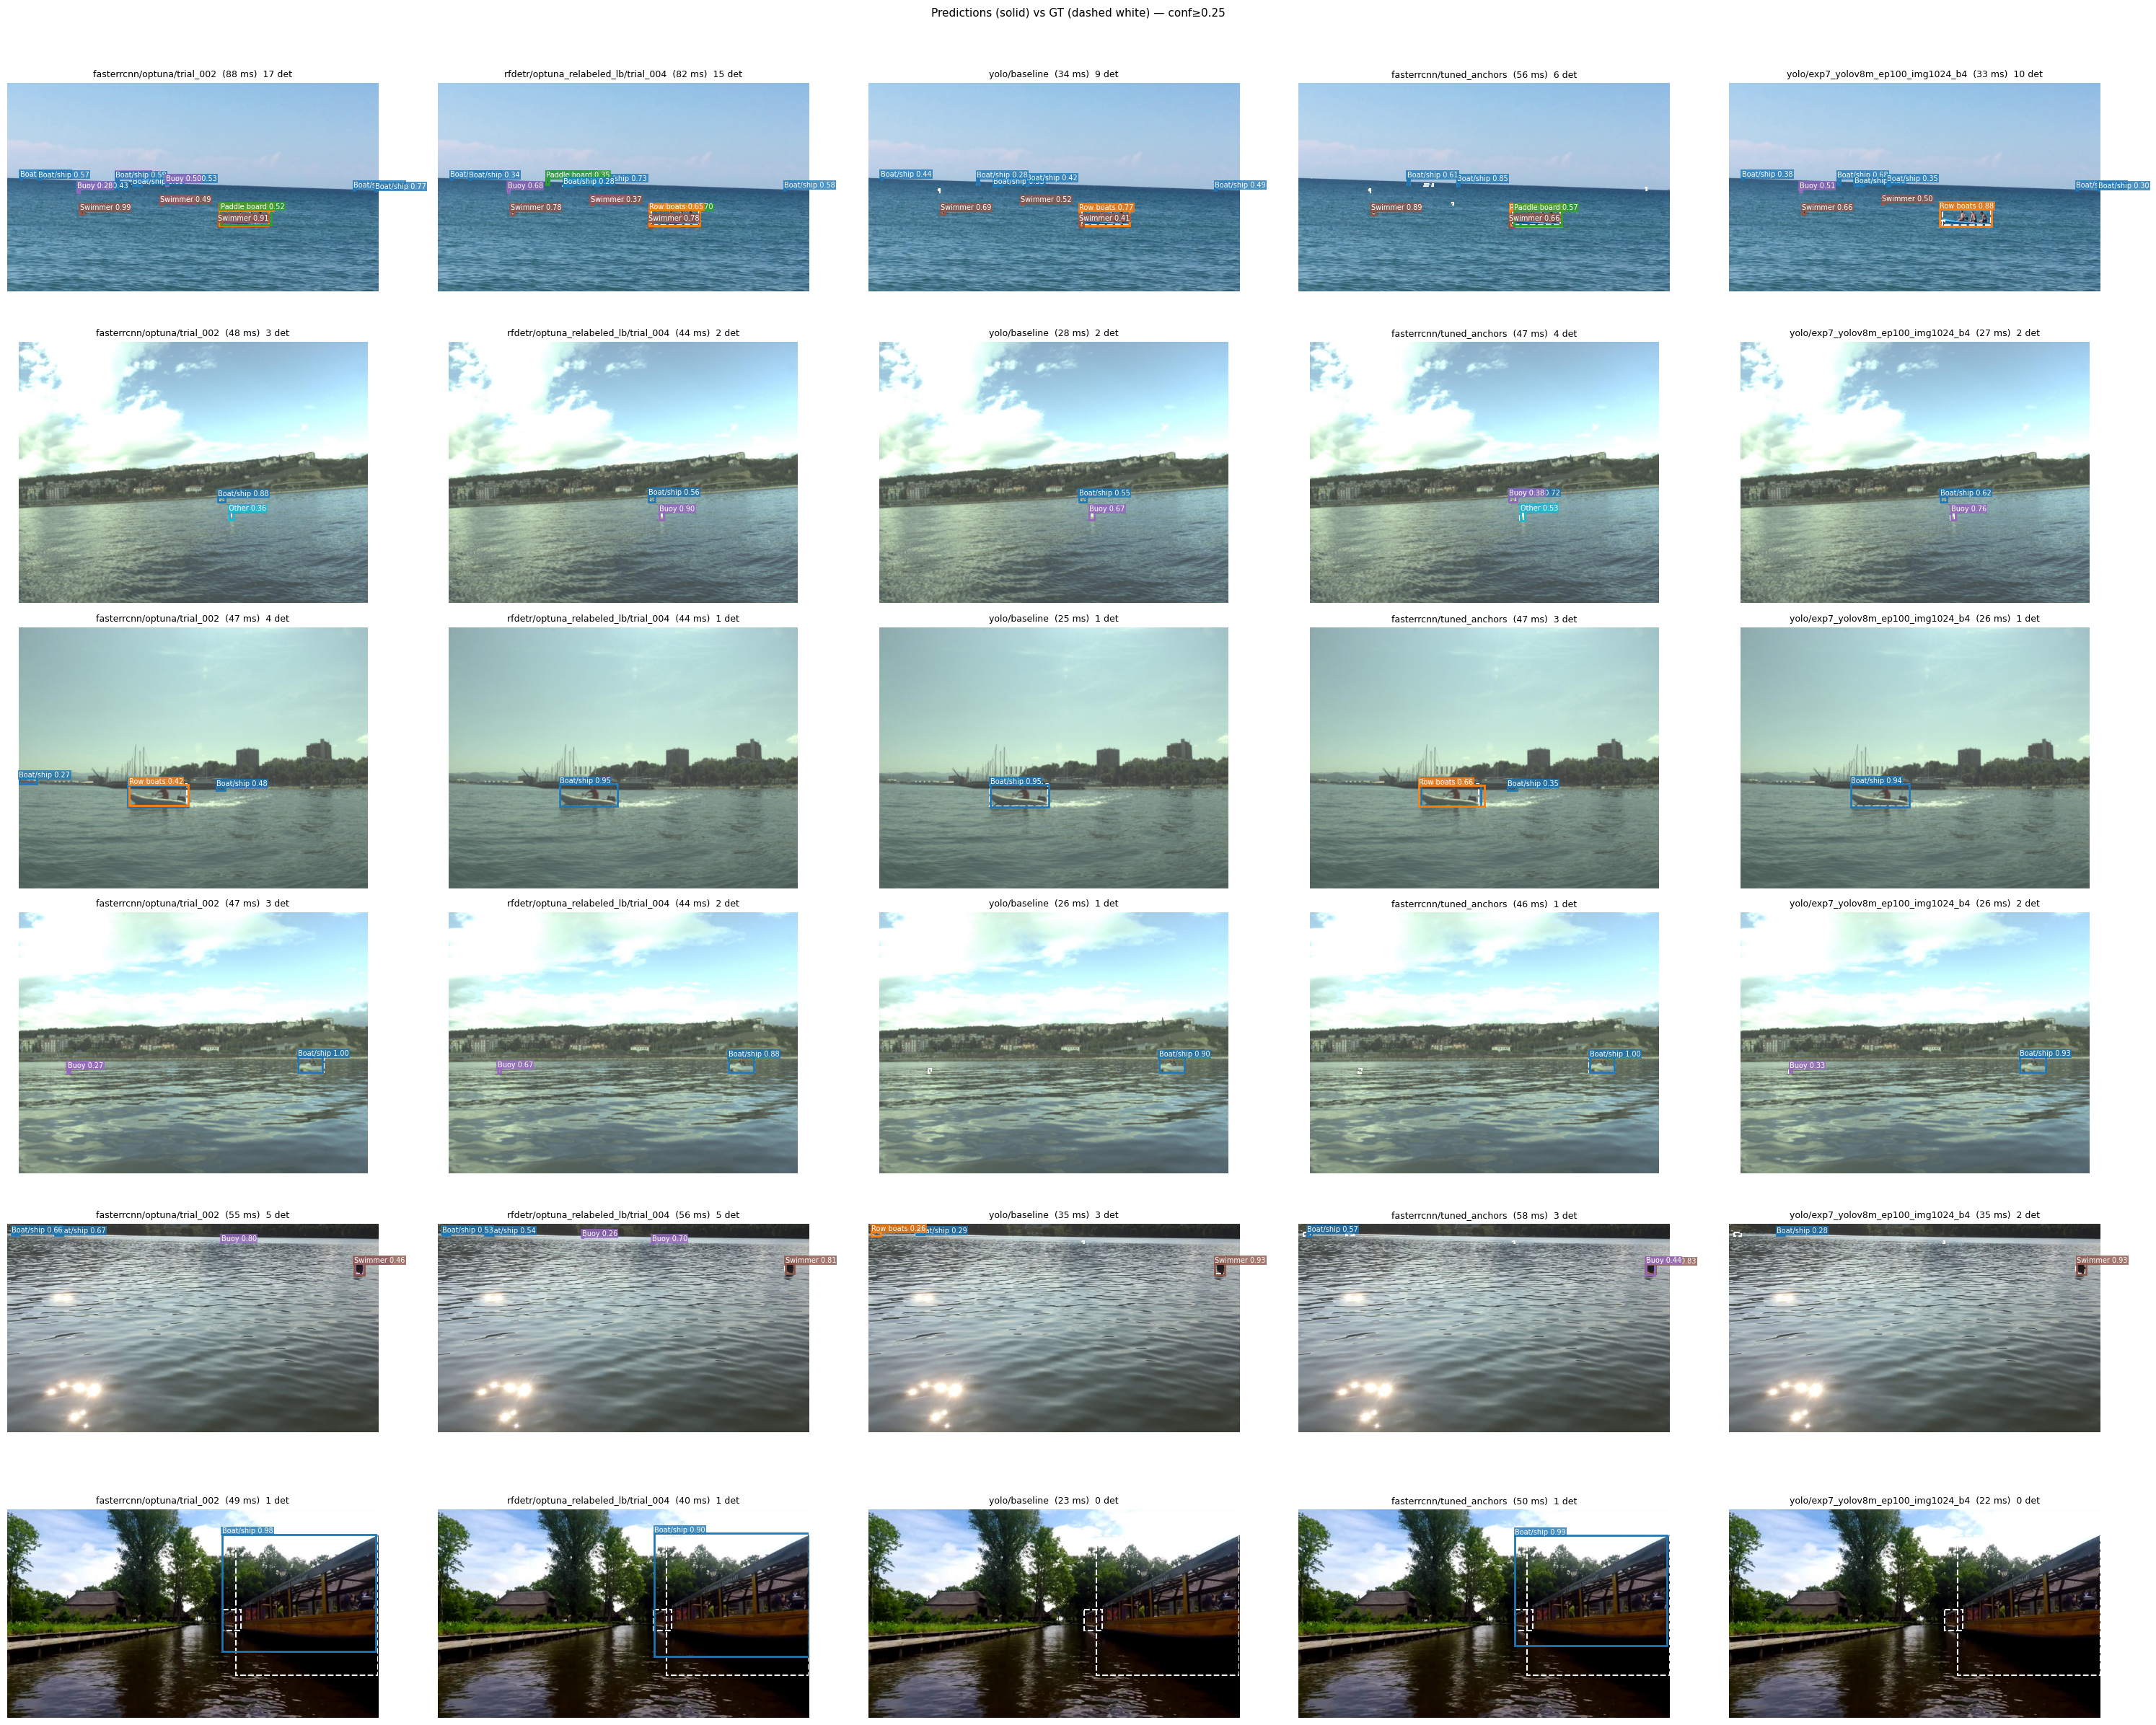

In [4]:
# ── Sample images and run inference ──────────────────────────────────────────
ids_with_gt = [i for i in img_meta if i in gt_by_img]
sample_ids  = random.sample(ids_with_gt, k=min(N_IMAGES, len(ids_with_gt)))

cmap   = plt.cm.get_cmap("tab10", N_CLASSES)
colors = [cmap(i)[:3] for i in range(N_CLASSES)]
ncols  = len(models)

fig, axes = plt.subplots(len(sample_ids), ncols,
                         figsize=(6 * ncols, 4 * len(sample_ids)), squeeze=False)

for row, img_id in enumerate(sample_ids):
    meta    = img_meta[img_id]
    pil_img = Image.open(DATA_ROOT / SPLIT / "images" / meta["file_name"]).convert("RGB")
    gt_anns = gt_by_img.get(img_id, [])

    for col, (mname, predict) in enumerate(models.items()):
        t0    = time.perf_counter()
        preds = predict(pil_img)
        ms    = (time.perf_counter() - t0) * 1000

        ax = axes[row][col]
        ax.imshow(pil_img)
        ax.axis("off")
        ax.set_title(f"{mname}  ({ms:.0f} ms)  {len(preds['boxes'])} det", fontsize=9)

        # ground-truth (dashed white)
        for a in gt_anns:
            x, y, w, h = a["bbox"]
            ax.add_patch(mpatches.Rectangle((x, y), w, h,
                linewidth=1.5, edgecolor="white", facecolor="none", linestyle="--"))

        # predictions (solid)
        for box, cls, score in zip(preds["boxes"], preds["labels"], preds["scores"]):
            x1, y1, x2, y2 = box
            c = colors[int(cls) % N_CLASSES]
            ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=c, facecolor="none"))
            ax.text(x1, y1-4, f"{CLASS_NAMES[int(cls)]} {score:.2f}",
                color="white", fontsize=7,
                bbox=dict(facecolor=c, alpha=0.8, pad=1, edgecolor="none"))

plt.suptitle(f"Predictions (solid) vs GT (dashed white) — conf≥{CONF_THRESH}",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()